# Auto MPG：燃費の違いと車両特性の関係

run_id: `v020-exp-07`。日本語で記録。データ取得・分析はJupyter MCPの実行セルのみ。秘密値は一切表示しない。

## 分析計画（データを読む前）
1. Kaggle SDKで指定公開データを検索し、ファイル一覧とメタデータを確認してCSV取得。owner/dataset slug、ファイル名、UTC取得日時、SHA-256を記録する。対応データがなければ実験停止（外部ミラーなし）。
2. データ定義manifestと分析前提manifestを作成し、欠損、重複、意味的範囲、カテゴリ、型の異常を確認。`horsepower`の欠損は記号を明示的に欠損へ変換し、完全ケースを主分析、補完を感度分析に用いる。
3. 燃費（MPGが高いほど良い）とのPearson/Spearman相関と不確実性を図表化。重量・排気量・気筒数・馬力の共線性を確認し、年式・originを含む調整モデルで条件付き関係を比較する。95%区間は因果効果ではない。
4. 乱数seedを固定。全車を記述対象とし、訓練/評価分離した交差検証はモデルの妥当性確認に用いる。外れ値除外・欠損処理・モデル仕様の感度を明示的な小さいグリッドで確認する。
5. 初回結果を読んで結論に関わる未解決点を選定し、最大3回の自然言語の追加依頼と実行を記録する。価値ある追加分析がなければ停止理由を記録。
6. 根拠セルの実出力から引用値を抽出してInsightを記録。全コードセルを上から再実行し、`notebook_audit(visual_audit=True)`とライフサイクル状態を保存する。

## 適用範囲
観察データの関連を調べる。介入の燃費改善効果は識別しない。独立参照データは提供されていないため、独立データ間検証や異常の独立照合は適用しない（同一CSVの別コピーは独立検証としない）。ML拡張のAutoML/クラスタリングは目的に不要。

## 実行・保存方式
Notebookセルの作成と手動更新は `project_manager.enqueue_write` の単一writer経由。実行は外側のJupyter MCP `execute_cell` で行い、MCPが実際のexecution_countと出力を保存する。カーネル内にMCPクライアントは提供されていないため `mcp_gateway.run_and_record` の自己呼出しや偽クライアントは用いない。これはCLI/MCPの接続境界であり、Jupytermindの不具合とは断定しない。長時間フェーズと手動書込みをlifecycleで追跡する。


### MCP保存との同期手順（再実行に必要）
実行中セルから同じNotebookをenqueue_writeで書き換えると、MCPのセル保存と競合してexecution_countが失われる例があった。これはJupyter MCPと外部ファイルwriterの境界として記録し、CLI/Kaggle固有問題とは別に扱うが、単独モジュールの不具合とは断定しない。APIセルでは主Notebookを書き換えず取得履歴を出力する。COMPILE_INSIGHTSはdata/evidence-staging.ipynbに実根拠とInsightを隔離保存する。外側のJupyter MCP bootstrapセルで、その実行終了後に生成Insightとmetadataだけを主Notebookへenqueue_writeで同期し、FINAL_AUDITを実行する。最終監査セルの保存終了後に監査metadataを同期する。全分析コードの実行はJupyter MCPだけで行う。


In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib
from datetime import datetime, timezone
from dataclasses import asdict
REPO = Path('/home/nahisaho/GitHub/jupytermind')
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from ai_data_scientist import project_manager, language_router, lifecycle
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-07-auto-mpg')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
run_id = 'v020-exp-07'
lifecycle.register_run(run_id, handle.notebook_path)
phase_log = []
def start_phase(name):
    if lifecycle.is_cancel_requested(run_id):
        lifecycle.mark_failed(run_id)
        raise RuntimeError('中止要求により処理を停止')
    lifecycle.mark_execution_start(run_id)
    phase_log.append({'phase': name, 'event': 'execution_start', 'at': datetime.now(timezone.utc).isoformat()})
def end_phase(name):
    lifecycle.mark_execution_end(run_id)
    phase_log.append({'phase': name, 'event': 'execution_end', 'at': datetime.now(timezone.utc).isoformat()})
def write_nb(mutation):
    lifecycle.mark_write_start(run_id)
    phase_log.append({'phase': 'notebook', 'event': 'write_start'})
    try:
        return project_manager.enqueue_write(handle, mutation)
    except Exception:
        lifecycle.mark_failed(run_id)
        raise
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'phase': 'notebook', 'event': 'write_end'})
print('言語:', language_router.detect_language('Auto MPGの燃費と車両特性の関係を日本語で分析する。'))
print('run_id:', run_id)
print('Notebook:', handle.notebook_path)
print('初期ライフサイクル:', asdict(lifecycle.get_run_status(run_id)))

def emit_evidence(message):
    display({'text/plain':message}, raw=True)


言語: ja
run_id: v020-exp-07
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-07-auto-mpg/notebooks/kaggle-v020-kaggle-exp-07-auto-mpg.ipynb
初期ライフサイクル: {'run_id': 'v020-exp-07', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-07-auto-mpg/notebooks/kaggle-v020-kaggle-exp-07-auto-mpg.ipynb', 'reason': None}


In [2]:
start_phase('kaggle取得')
lifecycle.mark_write_start(run_id)
phase_log.append({'phase':'kaggle取得','event':'write_start'})
try:
    # 認証・SDK出力は秘密値を含む可能性があるため表示しない。
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        search_results = api.dataset_list(search='auto mpg')
    found = [{'ref': str(d.ref), 'title': str(d.title)} for d in search_results]
    display(pd.DataFrame(found))
    dataset_slug = 'uciml/autompg-dataset'
    if dataset_slug not in [d['ref'] for d in found]:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            exact_results = api.dataset_list(search='autompg', user='uciml')
        found += [{'ref': str(d.ref), 'title': str(d.title)} for d in exact_results]
    if dataset_slug not in [d['ref'] for d in found]:
        raise LookupError('指定公開データがKaggle API検索結果に存在しない。外部ミラーへの切替は禁止。')
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        file_listing = api.dataset_list_files(dataset_slug)
        metadata_path = api.dataset_metadata(dataset_slug, path=str(data_dir))
    metadata = json.loads(Path(metadata_path).read_text(encoding='utf-8'))
    file_names = [str(f.name) for f in file_listing.files]
    print('対応する公開データ:', dataset_slug)
    print('APIファイル一覧:', file_names)
    csv_names = [name for name in file_names if name.lower().endswith('.csv')]
    if len(csv_names) != 1:
        raise ValueError('CSVファイルを一意に選択できないため停止')
    filename = csv_names[0]
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_download_file(dataset_slug, filename, path=str(data_dir), force=True, quiet=True)
    csv_path = data_dir / filename
    if not csv_path.exists():
        import zipfile
        archive_path = data_dir / (filename + '.zip')
        if not archive_path.exists():
            raise FileNotFoundError('Kaggle SDK取得ファイルが見つからない')
        with zipfile.ZipFile(archive_path) as archive:
            matches = [n for n in archive.namelist() if Path(n).name == Path(filename).name]
            if len(matches) != 1:
                raise ValueError('アーカイブ中の対象CSVが一意でない')
            csv_path.write_bytes(archive.read(matches[0]))
    provenance = {'owner_dataset_slug': dataset_slug, 'filename': filename,
                  'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                  'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                  'source_url': 'https://www.kaggle.com/datasets/' + dataset_slug,
                  'search': 'auto mpg', 'external_csv_mirror': False}
    description = str(metadata['info'].get('description', '') or '')
    print('取得履歴:', json.dumps(provenance, ensure_ascii=False, indent=2))
    print('Kaggleデータ説明（公開メタデータ）:', description[:14000])
except Exception as exc:
    lifecycle.mark_failed(run_id)
    # SDKの例外本文・トレースバックには秘密値があり得るので、種類と安全な説明だけを出す。
    raise RuntimeError('Kaggle取得失敗。外部ソースにはフォールバックしない。例外分類: ' + type(exc).__name__) from None
finally:
    lifecycle.mark_write_end(run_id)
    phase_log.append({'phase':'kaggle取得','event':'write_end'})
    end_phase('kaggle取得')


対応する公開データ: uciml/autompg-dataset
APIファイル一覧: ['auto-mpg.csv']
取得履歴: {
  "owner_dataset_slug": "uciml/autompg-dataset",
  "filename": "auto-mpg.csv",
  "retrieved_at_utc": "2026-10-01T16:40:07.286700+00:00",
  "sha256": "09a282cf12c7ab4ffb517b496b0dd1a8bac6e95977178cc7832c32044c32c3f6",
  "source_url": "https://www.kaggle.com/datasets/uciml/autompg-dataset",
  "search": "auto mpg",
  "external_csv_mirror": false
}
Kaggleデータ説明（公開メタデータ）: ### Context

The data is technical spec of cars. The dataset is downloaded from UCI Machine Learning Repository


### Content

1. Title: Auto-Mpg Data

2. Sources:
   (a) Origin:  This dataset was taken from the StatLib library which is
                maintained at Carnegie Mellon University. The dataset was 
                used in the 1983 American Statistical Association Exposition.
   (c) Date: July 7, 1993

3. Past Usage:
    -  See 2b (above)
    -  Quinlan,R. (1993). Combining Instance-Based and Model-Based Learning.
       In Proceedings on the Te

,ref,title
0,uciml/autompg-dataset,Auto-mpg dataset
1,yasserh/auto-mpg-dataset,Auto MPG Dataset
2,adhurimquku/ford-car-price-prediction,Ford Car Price Prediction
3,zsinghrahulk/auto-mpg,AUTO MPG
4,armanjitsingh/auto-mpg,Auto-MPG
5,raghupalem/auto-mpg-data-set,Auto MPG Data Set
6,donsalehi/auto-mpg-csv,auto-mpg.csv
7,jawadkhan65/auto-mpg-fuel-efficiency-prediction,Auto-MPG-Fuel-Efficiency-Prediction
8,fazilbtopal/auto85,1985 Automobile Dataset
9,serhiihonchar/auto-mpg,Auto MPG


## 接続・API対応ログ
初回のKaggle検索は成功。追加の公開メタデータ取得で、このインストール済みSDKには `dataset_view` が存在せず `AttributeError` となった。Kaggle SDKの `dataset_metadata` に修正して再取得する。対象データはAPIで見つかっており、外部CSVへのフォールバックは行わない。これはKaggle SDK互換性に固有の問題で、Jupytermind改善候補に含めない。Jupyter MCPの初期作成は親ディレクトリがないと失敗するため、project_managerで先に作成した。
独自の字形監査コードでfont_manager.findfontにリストを渡しTypeErrorとなった。FontPropertiesに修正した。分析作成コードの問題であり、Jupytermind起因ではない。

## データ定義・分析前提・意味的異常検査
出典の説明と実データを区別する。物理単位が公開辞書で確認できない場合は推定と明記し、MPGのkm/L換算やoriginの国ラベル化は行わない。`unresolved_fields()`はunknownのみを返すため、inferredも別途列挙する。車名の重複は測定の重複と同義ではなく、同名の別年式車両があり得る。

In [3]:
# データ定義・前提・意味的品質検査
start_phase('データ点検')
try:
    from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions, data_quality
    FV = data_definition.FieldValue
    ingested = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=10000)
    raw = ingested.dataframe
    expected_columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']
    if raw.columns.tolist() != expected_columns or ingested.truncated:
        raise ValueError('期待したAuto MPGスキーマまたは取得行数上限に違反')
    df = raw.rename(columns={'model year': 'model_year', 'car name': 'car_name'}).copy()
    numeric_columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']
    sentinel_count = int(df['horsepower'].astype(str).str.strip().eq('?').sum())
    df['horsepower'] = df['horsepower'].replace('?', np.nan)
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='raise')
    dup_report = cleaning.clean_dataset(df, operation='drop_duplicates')
    df = dup_report.dataframe
    complete_report = cleaning.clean_dataset(df, operation='drop_na', columns=numeric_columns)
    complete = complete_report.dataframe.copy()
    print('CLEANING:', json.dumps({'raw_rows': len(raw), 'question_mark_missing': sentinel_count,
          'duplicate_rows_removed': dup_report.rows_removed, 'complete_rows': len(complete),
          'missing_rows_removed': complete_report.rows_removed, 'columns_affected': complete_report.columns_affected}, ensure_ascii=False))
    report_eda = eda.explore(df)
    display(pd.DataFrame(report_eda.missing_summary).T)
    display(df[numeric_columns].describe().T)
    print('型:', report_eda.dtypes)
    print('car_nameカテゴリ概要:', report_eda.categorical_summary['car_name'])
    print('horsepower欠損行（削除の影響を確認）:')
    display(df.loc[df.horsepower.isna(), ['mpg', 'weight', 'model_year', 'origin', 'car_name']])
    dictionary_source = provenance['source_url'] + ' (dataset_metadata/info/description)'
    definitions = {
        'mpg': ('市街地サイクルの燃料消費を表す燃費。値が高いほど良い', 'miles per gallon', 'verified'),
        'cylinders': ('気筒数と推定（公開辞書は離散値とだけ記載）', '個', 'inferred'),
        'displacement': ('エンジン排気量と推定', 'cubic inches と推定', 'inferred'),
        'horsepower': ('エンジン馬力と推定。測定規格は不明', 'horsepower と推定', 'inferred'),
        'weight': ('車両重量と推定', 'pounds と推定', 'inferred'),
        'acceleration': ('加速所要時間と推定。0-60mphかは未確認', 'seconds と推定', 'inferred'),
        'model_year': ('年式コード70-82。1970-1982と推定', '年式コード1単位', 'inferred'),
        'origin': ('出自カテゴリコード1/2/3。国・地域ラベルは未検証', 'カテゴリコード', 'unknown'),
        'car_name': ('車名文字列。名称はユニークとは限らない', '文字列', 'verified')}
    variable_manifest = {col: {'definition': FV(desc, status, dictionary_source if status == 'verified' else '列名と実データから推定'),
                               'unit': FV(unit, status, dictionary_source if status == 'verified' else '列名と値域から推定')} 
                         for col, (desc, unit, status) in definitions.items()}
    variable_manifest['mpg']['gallon_standard'] = FV(None, 'unknown', '公開説明に米国/英ガロンの明示なし')
    definition_manifest = data_definition.build_manifest(
        source={'identity': FV(provenance, 'verified', 'Kaggle SDK実取得とSHA-256'),
                'license': FV(metadata['info'].get('licenses'), 'verified', 'Kaggle SDK公開メタデータ'),
                'measurement_protocol': FV(None, 'unknown', '市街地サイクルの具体的測定条件は不明')},
        dataset_scope={'rows': FV(len(df), 'verified', 'CSV実測'),
                       'selection': FV('元データからmpg不明の8件が除かれた398件', 'verified', dictionary_source),
                       'population_representativeness': FV(None, 'unknown', '抽出母集団・標本設計は不明')},
        variables=variable_manifest,
        transformations=('horsepowerの?を欠損へ変換', '完全重複のみ削除', '全変数モデルの主分析は完全ケース'))
    print('DATA_DEFINITION_MANIFEST:', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str, indent=2))
    unresolved = definition_manifest.unresolved_fields()
    inferred = [(f'variables.{c}.{k}', asdict(v)) for c, fields in definition_manifest.variables.items() for k,v in fields.items() if v.status == 'inferred']
    print('UNKNOWN_FIELDS:', [(p, asdict(v)) for p,v in unresolved])
    print('INFERRED_FIELDS（別途明示）:', inferred)
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target': 'このCSVの観察車両における燃費差', 'estimates': '相関と条件付き関連; 介入効果ではない'},
        causal_scope='associational', sampling={'n': len(df), 'seed': 20261002, 'mode': '全観測; ブートストラップ/分割のみ乱数を使用'},
        assumptions=(
            analysis_assumptions.Assumption('missing', '馬力欠損の除外で関連の方向が変わらない', 'assumed', impact_if_false='完全ケースの係数に選択バイアス', conclusion_critical=True),
            analysis_assumptions.Assumption('functional', '主要関係を線形近似しても実質的結論が変わらない', 'assumed', impact_if_false='調整係数の大きさや追加説明力が変わる', conclusion_critical=True),
            analysis_assumptions.Assumption('iid', '車名の重複や同年式の依存は95%区間に大きく影響しない', 'assumed', impact_if_false='区間が過小評価され得る', conclusion_critical=True),
            analysis_assumptions.Assumption('causal', '無作為化・交絡の十分な測定があり介入効果を識別できる', 'rejected', impact_if_false='因果結論は禁止', conclusion_critical=False),
            analysis_assumptions.Assumption('generalize', '現代車や全市場への代表性が保証される', 'rejected', impact_if_false='この標本外への一般化は禁止', conclusion_critical=False)))
    print('ANALYSIS_ASSUMPTION_MANIFEST:', json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
    print('前提チェック（全指摘を開示）:', [asdict(x) for x in analysis_assumptions.check_manifest(assumptions)])
    schema = {'mpg': {'min': 1, 'max': 100, 'not_null': True},
              'cylinders': {'allowed': [3,4,5,6,8], 'not_null': True},
              'displacement': {'min': 1, 'max': 1000, 'not_null': True},
              'horsepower': {'min': 1, 'max': 1000, 'not_null': True},
              'weight': {'min': 100, 'max': 10000, 'not_null': True},
              'acceleration': {'min': 1, 'max': 60, 'not_null': True},
              'model_year': {'min': 70, 'max': 82, 'not_null': True},
              'origin': {'allowed': [1,2,3], 'not_null': True},
              'car_name': {'not_null': True, 'unique': True}}
    semantic_findings = data_quality.detect_anomalies(df, schema=schema)
    print('意味的検査ルール（保守的な仮定; 正式測定基準ではない）:', schema)
    print('SEMANTIC_ANOMALIES:', json.dumps([asdict(x) for x in semantic_findings], ensure_ascii=False, default=str))
    assert len(df) == 398 and len(complete) == 392
    assert sentinel_count == 6 and int(df.horsepower.isna().sum()) == 6
    print('スキーマ・件数・欠損照合: PASS')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('データ点検')


CLEANING: {"raw_rows": 398, "question_mark_missing": 6, "duplicate_rows_removed": 0, "complete_rows": 392, "missing_rows_removed": 6, "columns_affected": ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin"]}
型: {'mpg': 'float64', 'cylinders': 'int64', 'displacement': 'float64', 'horsepower': 'float64', 'weight': 'int64', 'acceleration': 'float64', 'model_year': 'int64', 'origin': 'int64', 'car_name': 'str'}
car_nameカテゴリ概要: {'unique_count': 305, 'top_values': [{'value': 'ford pinto', 'count': 6, 'ratio': 0.01507537688442211}, {'value': 'ford maverick', 'count': 5, 'ratio': 0.01256281407035176}, {'value': 'amc matador', 'count': 5, 'ratio': 0.01256281407035176}, {'value': 'toyota corolla', 'count': 5, 'ratio': 0.01256281407035176}, {'value': 'chevrolet impala', 'count': 4, 'ratio': 0.010050251256281407}, {'value': 'amc hornet', 'count': 4, 'ratio': 0.010050251256281407}, {'value': 'peugeot 504', 'count': 4, 'ratio': 0.010050251256281407}, {

,missing_count,missing_ratio
mpg,0.0,0.000000
cylinders,0.0,0.000000
displacement,0.0,0.000000
horsepower,6.0,0.015075
weight,0.0,0.000000
acceleration,0.0,0.000000
model_year,0.0,0.000000
origin,0.0,0.000000
car_name,0.0,0.000000


,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


,mpg,weight,model_year,origin,car_name
32,25.0,2046,71,1,ford pinto
126,21.0,2875,74,1,ford maverick
330,40.9,1835,80,2,renault lecar deluxe
336,23.6,2905,80,1,ford mustang cobra
354,34.5,2320,81,2,renault 18i
374,23.0,3035,82,1,amc concord dl


## 初回分析：関係の強さ
相関は同時に変動する程度であり、因果ではない。Pearsonは線形関連、Spearmanは順位関連を捉える。相関区間はFisher近似。条件付き回帰ではHC3の不均一分散頑健標準誤差を使う。馬力以外は398件、全特性モデルは392件を使い、originはカテゴリ変数として扱う。

In [4]:
# 初回分析: 周辺相関と調整後の関連
start_phase('初回統計')
try:
    from ai_data_scientist import stats_analysis
    from scipy import stats
    import statsmodels.formula.api as smf
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import matplotlib.pyplot as plt
    features = ['weight', 'displacement', 'cylinders', 'horsepower', 'model_year', 'acceleration']
    labels_ja = {'weight':'重量', 'displacement':'排気量', 'cylinders':'気筒数', 'horsepower':'馬力', 'model_year':'年式コード', 'acceleration':'加速時間（推定）'}
    corr_rows = []
    for col in features:
        pair = df[['mpg', col]].dropna()
        result = stats_analysis.correlation(pair, col, 'mpg', language='ja')
        z = np.arctanh(result.statistic)
        half = stats.norm.ppf(.975)/np.sqrt(len(pair)-3)
        lo, hi = np.tanh([z-half, z+half])
        rho = stats.spearmanr(pair[col], pair.mpg).statistic
        corr_rows.append({'feature':col, '特性':labels_ja[col], 'n':len(pair), 'Pearson_r':result.statistic,
                          'CI_low':lo, 'CI_high':hi, 'Spearman_rho':rho, 'p':result.p_value})
        print(col + ': ' + result.interpretation)
    corr_table = pd.DataFrame(corr_rows).sort_values('Pearson_r')
    display(corr_table.drop(columns='p').round(4))
    emit_evidence('EVIDENCE_WEIGHT_R=' + format(corr_table.set_index('feature').loc['weight','Pearson_r'], '.6f'))
    emit_evidence('EVIDENCE_YEAR_R=' + format(corr_table.set_index('feature').loc['model_year','Pearson_r'], '.6f'))
    print('説明変数間の相関:')
    display(complete[features].corr().round(3))
    reduced_formula = 'mpg ~ I(weight/1000) + model_year + C(origin)'
    full_formula = 'mpg ~ I(weight/1000) + displacement + cylinders + horsepower + acceleration + model_year + C(origin)'
    reduced_fit = smf.ols(reduced_formula, data=complete).fit(cov_type='HC3')
    full_fit = smf.ols(full_formula, data=complete).fit(cov_type='HC3')
    def coefficient_table(fit):
        ci = fit.conf_int()
        return pd.DataFrame({'coefficient':fit.params, 'HC3_SE':fit.bse, 'CI_low':ci[0], 'CI_high':ci[1], 'p':fit.pvalues})
    print('簡潔モデル: 同じ年式・originで重量の関連を比較（重量1000記録単位あたりMPG）')
    display(coefficient_table(reduced_fit).round(4))
    print('全特性モデル: その他の特性を固定した条件付き関連（共線性に注意）')
    display(coefficient_table(full_fit).round(4))
    vif_rows = [{'term':name, 'VIF':variance_inflation_factor(full_fit.model.exog, i)}
                for i,name in enumerate(full_fit.model.exog_names) if name != 'Intercept']
    display(pd.DataFrame(vif_rows).round(2))
    emit_evidence('EVIDENCE_MAX_VIF=' + format(max(row['VIF'] for row in vif_rows),'.6f'))
    delta_r2 = full_fit.rsquared - reduced_fit.rsquared
    print('MODEL_R2:', {'reduced':reduced_fit.rsquared,'full':full_fit.rsquared,'additional_features_delta_R2':delta_r2})
    emit_evidence('EVIDENCE_REDUCED_WEIGHT=' + format(reduced_fit.params['I(weight / 1000)'], '.6f'))
    emit_evidence('EVIDENCE_REDUCED_YEAR=' + format(reduced_fit.params['model_year'], '.6f'))
    origin_summary = df.groupby('origin', observed=True).agg(n=('mpg','size'), mpg_mean=('mpg','mean'), mpg_median=('mpg','median'), weight_mean=('weight','mean'), year_mean=('model_year','mean'))
    print('origin群の記述統計（国ラベルは未確認なのでコードのまま）:')
    display(origin_summary.round(3))
    print('初回分析の留保: 正規近似の相関区間とHC3区間は独立性を仮定する。originを順序数値として相関化しない。共線性のある特性の単独順位を因果的な重要度と呼ばない。')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('初回統計')


weight: 相関係数は -0.8317 (p=2.973e-103) で、強い負の相関が見られます。
displacement: 相関係数は -0.8042 (p=1.656e-91) で、強い負の相関が見られます。
cylinders: 相関係数は -0.7754 (p=4.504e-81) で、強い負の相関が見られます。
horsepower: 相関係数は -0.7784 (p=7.032e-81) で、強い負の相関が見られます。
model_year: 相関係数は 0.5793 (p=4.845e-37) で、中程度の正の相関が見られます。
acceleration: 相関係数は 0.4203 (p=1.823e-18) で、中程度の正の相関が見られます。
説明変数間の相関:
簡潔モデル: 同じ年式・originで重量の関連を比較（重量1000記録単位あたりMPG）
全特性モデル: その他の特性を固定した条件付き関連（共線性に注意）
MODEL_R2: {'reduced': np.float64(0.8190347755921505), 'full': np.float64(0.8241994699119172), 'additional_features_delta_R2': np.float64(0.005164694319766627)}
origin群の記述統計（国ラベルは未確認なのでコードのまま）:
初回分析の留保: 正規近似の相関区間とHC3区間は独立性を仮定する。originを順序数値として相関化しない。共線性のある特性の単独順位を因果的な重要度と呼ばない。


,feature,特性,n,Pearson_r,CI_low,CI_high,Spearman_rho
0,weight,重量,398,-0.8317,-0.8597,-0.7987,-0.8749
1,displacement,排気量,398,-0.8042,-0.8364,-0.7665,-0.8557
3,horsepower,馬力,392,-0.7784,-0.8147,-0.7361,-0.8536
2,cylinders,気筒数,398,-0.7754,-0.8118,-0.7330,-0.8219
5,acceleration,加速時間（推定）,398,0.4203,0.3359,0.4980,0.4387
4,model_year,年式コード,398,0.5793,0.5100,0.6411,0.5735


EVIDENCE_WEIGHT_R=-0.831741

EVIDENCE_YEAR_R=0.579267

,weight,displacement,cylinders,horsepower,model_year,acceleration
weight,1.000,0.933,0.898,0.865,-0.309,-0.417
displacement,0.933,1.000,0.951,0.897,-0.370,-0.544
cylinders,0.898,0.951,1.000,0.843,-0.346,-0.505
horsepower,0.865,0.897,0.843,1.000,-0.416,-0.689
model_year,-0.309,-0.370,-0.346,-0.416,1.000,0.290
acceleration,-0.417,-0.544,-0.505,-0.689,0.290,1.000


...

,term,VIF
0,C(origin)[T.2],1.65
1,C(origin)[T.3],1.76
2,I(weight / 1000),11.07
3,displacement,22.94
4,cylinders,10.74
5,horsepower,9.96
6,acceleration,2.63
7,model_year,1.30


EVIDENCE_MAX_VIF=22.937950

EVIDENCE_REDUCED_WEIGHT=-5.887005

EVIDENCE_REDUCED_YEAR=0.769849

,n,mpg_mean,mpg_median,weight_mean,year_mean
origin,,,,,
1,249,20.084,18.5,3361.932,75.610
2,70,27.891,26.5,2423.300,75.814
3,79,30.451,31.6,2221.228,77.443


## 初回図表
MPGが高いほど燃費が良い。重量の単位は推定で、図の相関係数は無単位。強い相関の特性同士も関連するため、それぞれが独立の燃費要因だとは限らない。

図表は日本語字体の字形被覆と描画警告を点検。相関は交絡を調整していない。


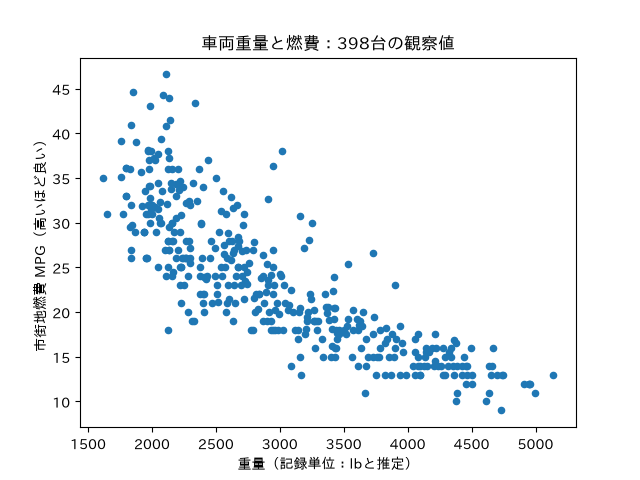

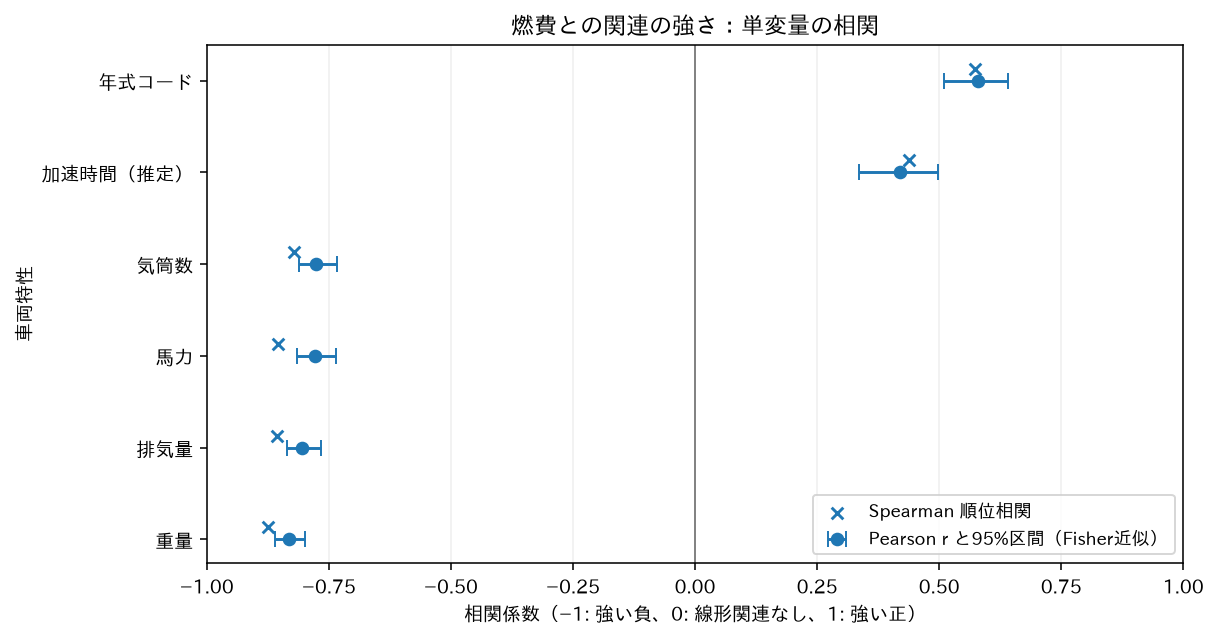

In [5]:
# FIG_INITIAL: 相関の強さと散布図
start_phase('初回図表')
try:
    from ai_data_scientist import visualization
    import warnings
    from matplotlib import font_manager, ft2font
    figure_registry = {}
    def publish_png(png, tag, metadata_chart):
        output = visualization.build_image_output(png)
        display(output['data'], raw=True)
        figure_registry[tag] = metadata_chart
    scatter_png = visualization.render_chart(df, kind='scatter', x='weight', y='mpg',
                          title='車両重量と燃費：398台の観察値', xlabel='重量（記録単位：lbと推定）', ylabel='市街地燃費 MPG（高いほど良い）')
    def render_figure(fig, tag, title, xlabel, ylabel, legend):
        font_path = font_manager.findfont(font_manager.FontProperties(family=plt.rcParams['font.family']))
        cmap = ft2font.FT2Font(font_path).get_charmap()
        all_text = ''.join(t.get_text() for t in fig.findobj(plt.Text))
        missing = sorted({ord(ch) for ch in all_text if not ch.isspace() and ord(ch) not in cmap})
        with warnings.catch_warnings(record=True) as ws:
            warnings.simplefilter('always')
            buffer = io.BytesIO()
            fig.savefig(buffer, format='png', dpi=140, bbox_inches='tight')
        glyph_warnings = [str(w.message) for w in ws if 'Glyph' in str(w.message)]
        if missing or glyph_warnings:
            raise RuntimeError('図表の字体欠落: ' + str(missing) + str(glyph_warnings))
        plt.close(fig)
        publish_png(buffer.getvalue(), tag, {'missing_glyphs':missing, 'title':title,
                     'xlabel':xlabel, 'ylabel':ylabel, 'legend':legend, 'font_path':str(font_path)})
    scatter_output = visualization.build_image_output(scatter_png)
    display(scatter_output['data'], raw=True)
    fig, ax = plt.subplots(figsize=(9,4.8))
    order = corr_table.reset_index(drop=True)
    positions = np.arange(len(order))
    ax.errorbar(order.Pearson_r, positions, xerr=[order.Pearson_r-order.CI_low, order.CI_high-order.Pearson_r], fmt='o', capsize=4, label='Pearson r と95%区間（Fisher近似）')
    ax.scatter(order.Spearman_rho, positions+.13, marker='x', label='Spearman 順位相関')
    ax.set_yticks(positions, order['特性'])
    ax.axvline(0, color='gray', linewidth=1)
    ax.set(xlim=(-1,1), xlabel='相関係数（−1: 強い負、0: 線形関連なし、1: 強い正）', ylabel='車両特性', title='燃費との関連の強さ：単変量の相関')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=.2)
    render_figure(fig, 'FIG_INITIAL', ax.get_title(), ax.get_xlabel(), ax.get_ylabel(), 'Pearson r と95%区間 / Spearman 順位相関; 散布図は全車観察値')
    print('図表は日本語字体の字形被覆と描画警告を点検。相関は交絡を調整していない。')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('初回図表')


## 反復依頼履歴：反復1
### 追加依頼（原文）
重量と燃費の関係は直線ではなく曲線に見えます。重量の二次項を入れ、年式・originを調整した関係の方向と大きさを確認してください。全特性を加えたモデルとも同じ分割の交差検証で比較し、排気量や馬力を独立の主要要因と呼べるか、初回結論を見直してください。

### 選定理由
初回の散布図に曲線傾向があり、全特性の排気量係数が単変量の負相関と逆向き。VIFも高く、直線係数の大きさや独立重要度の解釈に実質的影響がある。重量二次モデルと、気筒数をカテゴリ扱いした全特性非線形モデルを追加し、30個の共通分割で誤差を比較する。

In [6]:
# ITERATION_1: 非線形性と交差検証
start_phase('反復1 非線形モデル')
try:
    from sklearn.model_selection import RepeatedKFold
    formulas = {
        '簡潔・線形': reduced_formula,
        '全特性・線形': full_formula,
        '簡潔・重量二次': reduced_formula + ' + I((weight/1000)**2)',
        '全特性・非線形': 'mpg ~ I(weight/1000) + I((weight/1000)**2) + displacement + C(cylinders) + horsepower + I(horsepower**2) + acceleration + model_year + C(origin)'}
    nonlinear_formula = formulas['簡潔・重量二次']
    nonlinear_fit = smf.ols(nonlinear_formula, data=complete).fit(cov_type='HC3')
    display(coefficient_table(nonlinear_fit).round(4))
    splits = list(RepeatedKFold(n_splits=10, n_repeats=3, random_state=20261002).split(complete))
    cv_rows, fold_results = [], []
    for name, formula in formulas.items():
        predictions, truths = [], []
        fold_rmses = []
        for fold, (train, test) in enumerate(splits):
            train_data, test_data = complete.iloc[train], complete.iloc[test]
            fitted = smf.ols(formula, data=train_data).fit()
            pred = fitted.predict(test_data).to_numpy()
            truth = test_data.mpg.to_numpy()
            rmse = float(np.sqrt(np.mean((pred-truth)**2)))
            fold_rmses.append(rmse)
            predictions.extend(pred.tolist())
            truths.extend(truth.tolist())
            fold_results.append({'model':name, 'fold':fold, 'RMSE':rmse})
        y,p = np.asarray(truths),np.asarray(predictions)
        cv_rows.append({'model':name,'pooled_RMSE':np.sqrt(np.mean((p-y)**2)), 'pooled_MAE':np.mean(abs(p-y)),
                        'pooled_R2':1-np.sum((p-y)**2)/np.sum((y-y.mean())**2),
                        'fold_RMSE_SD':np.std(fold_rmses,ddof=1), 'folds':len(splits)})
    cv_table = pd.DataFrame(cv_rows)
    display(cv_table.round(4))
    improvement = (cv_table.set_index('model').loc['簡潔・線形','pooled_RMSE'] - cv_table.set_index('model').loc['簡潔・重量二次','pooled_RMSE']) / cv_table.set_index('model').loc['簡潔・線形','pooled_RMSE']
    emit_evidence('EVIDENCE_QUADRATIC_RMSE=' + format(cv_table.set_index('model').loc['簡潔・重量二次','pooled_RMSE'],'.6f'))
    emit_evidence('EVIDENCE_LINEAR_RMSE=' + format(cv_table.set_index('model').loc['簡潔・線形','pooled_RMSE'],'.6f'))
    emit_evidence('EVIDENCE_RMSE_IMPROVEMENT=' + format(improvement,'.6f'))
    fixed_weights = [2000,2500,3000,3500,4000,4500]
    derivative_rows = []
    b1 = nonlinear_fit.params['I(weight / 1000)']
    b2 = nonlinear_fit.params['I((weight / 1000) ** 2)']
    for w in fixed_weights:
        derivative_rows.append({'重量記録値':w, '重量1000単位あたり局所傾き_MPG':b1 + 2*b2*w/1000})
    derivative_table = pd.DataFrame(derivative_rows)
    display(derivative_table.round(4))
    emit_evidence('EVIDENCE_QUADRATIC_WEIGHT3000=' + format(b1+6*b2,'.6f'))
    emit_evidence('EVIDENCE_QUADRATIC_YEAR=' + format(nonlinear_fit.params['model_year'],'.6f'))
    print('曲線モデルの局所傾きは小さい重量域ほど負の絶対値が大きい。局所微分は1000単位の実介入効果ではない。')
    print('CVの分割は全モデルで共通。各fitは訓練行のみ。カテゴリ支持を満たして予測。foldのSDは95%信頼区間ではない。モデル選択後の成績は外部検証ではなく楽観性が残る。')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('反復1 非線形モデル')


曲線モデルの局所傾きは小さい重量域ほど負の絶対値が大きい。局所微分は1000単位の実介入効果ではない。
CVの分割は全モデルで共通。各fitは訓練行のみ。カテゴリ支持を満たして予測。foldのSDは95%信頼区間ではない。モデル選択後の成績は外部検証ではなく楽観性が残る。


,coefficient,HC3_SE,CI_low,CI_high,p
Intercept,-1.3791,4.4334,-10.0685,7.3103,0.7558
C(origin)[T.2],1.3658,0.5993,0.1912,2.5405,0.0227
C(origin)[T.3],0.9120,0.5230,-0.1130,1.9371,0.0812
I(weight / 1000),-20.3318,1.4801,-23.2327,-17.4308,0.0000
model_year,0.8382,0.0496,0.7410,0.9354,0.0000
I((weight / 1000) ** 2),2.2177,0.2136,1.7990,2.6364,0.0000


,model,pooled_RMSE,pooled_MAE,pooled_R2,fold_RMSE_SD,folds
0,簡潔・線形,3.3615,2.5360,0.8140,0.4606,30
1,全特性・線形,3.3488,2.5614,0.8154,0.4007,30
2,簡潔・重量二次,3.0259,2.2210,0.8493,0.4700,30
3,全特性・非線形,2.9054,2.1100,0.8611,0.4863,30


EVIDENCE_QUADRATIC_RMSE=3.025907

EVIDENCE_LINEAR_RMSE=3.361509

EVIDENCE_RMSE_IMPROVEMENT=0.099837

,重量記録値,重量1000単位あたり局所傾き_MPG
0,2000,-11.4610
1,2500,-9.2433
2,3000,-7.0257
3,3500,-4.8080
4,4000,-2.5903
5,4500,-0.3726


EVIDENCE_QUADRATIC_WEIGHT3000=-7.025660

EVIDENCE_QUADRATIC_YEAR=0.838197

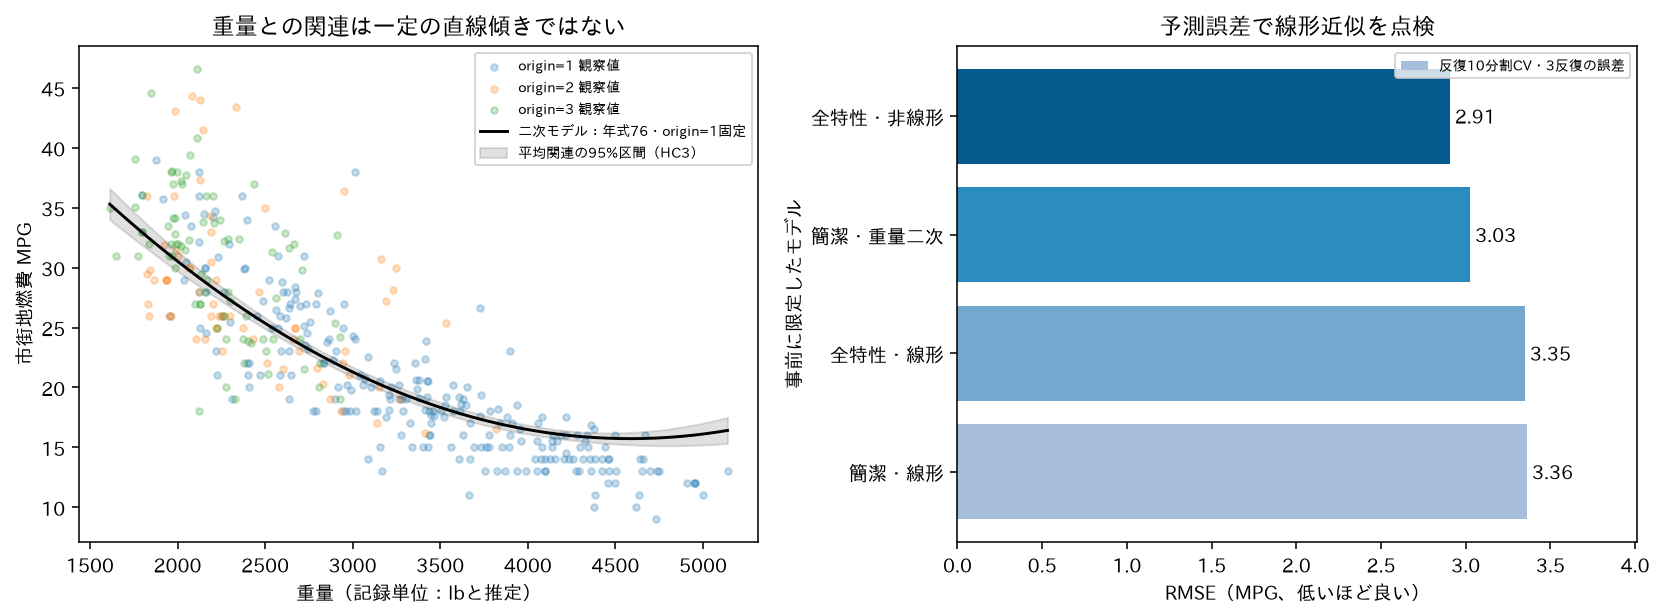

In [7]:
# FIG_NONLINEAR: 年式・originを固定した関連曲線
start_phase('非線形図表')
try:
    fig, axes = plt.subplots(1,2,figsize=(12,4.5))
    ax = axes[0]
    for code, group in complete.groupby('origin'):
        ax.scatter(group.weight, group.mpg, s=12, alpha=.25, label=f'origin={code} 観察値')
    grid = pd.DataFrame({'weight':np.linspace(complete.weight.min(),complete.weight.max(),200),'model_year':76,'origin':1})
    pred = nonlinear_fit.get_prediction(grid).summary_frame()
    ax.plot(grid.weight, pred['mean'], color='black', label='二次モデル：年式76・origin=1固定')
    ax.fill_between(grid.weight, pred.mean_ci_lower, pred.mean_ci_upper, color='black', alpha=.12, label='平均関連の95%区間（HC3）')
    ax.set(title='重量との関連は一定の直線傾きではない', xlabel='重量（記録単位：lbと推定）', ylabel='市街地燃費 MPG')
    ax.legend(fontsize=7)
    ax2 = axes[1]
    ax2.barh(cv_table['model'], cv_table.pooled_RMSE, color=['#a6bddb','#74a9cf','#2b8cbe','#045a8d'], label='反復10分割CV・3反復の誤差')
    for i,row in cv_table.iterrows():
        ax2.text(row.pooled_RMSE+.03, i, f'{row.pooled_RMSE:.2f}', va='center')
    ax2.set(xlim=(0,cv_table.pooled_RMSE.max()+.65), xlabel='RMSE（MPG、低いほど良い）', ylabel='事前に限定したモデル',title='予測誤差で線形近似を点検')
    ax2.legend(fontsize=7)
    fig.tight_layout()
    render_figure(fig,'FIG_NONLINEAR','調整後曲線と交差検証','重量 / CV RMSE（MPG）','燃費 MPG / モデル','origin観察値、二次モデル、HC3平均区間、CV誤差')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('非線形図表')


## 反復1の読直し：結果と残る限界
重量二次モデルは共通分割CVのRMSEを改善し、初回の線形近似だけでは不十分だった。全特性の非線形モデルにはさらに小さい追加改善があるため「その他の特性は無関係」とは結論しない。重量・年式の関連方向は保たれるが、originの係数は曲線仕様で縮小する。重い領域で二次曲線が折り返すため、全重量域で単調または一定の大きさとする結論は保留。数値の根拠は反復1セルと最終Insightで引用する。

## 反復依頼履歴：反復2
### 追加依頼（原文）
非線形モデルでは重量約4500を超える領域で曲線が折り返しています。重量3000付近の負の関連と年式の正の関連は、対数重量モデル、馬力欠損の中央値補完、影響の強い観測の除外でも保たれるか確認してください。また、同じ車名や年式の依存を考慮した区間と交差検証を調べ、origin差の解釈と重量域の限界を明確にしてください。

### 選定理由
曲線の重量域依存に加え、馬力欠損6件、car_nameの反復、同年式の依存を未検証のままにしていた。16仕様（4モデル×2欠損処理×2影響処理）を予算内で点検し、cluster区間、車名群分割、年式群分割を追加する。20%の安定性許容はこの診断の事前に明示する便宜的基準で、科学的普遍閾値ではない。

In [8]:
# ITERATION_2: 感度・依存・重量域の点検
start_phase('反復2 感度分析')
try:
    from ai_data_scientist import sensitivity
    from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
    log_formula = 'mpg ~ np.log(weight/1000) + model_year + C(origin)'
    log_fit = smf.ols(log_formula, data=complete).fit(cov_type='HC3')
    spec_formulas = {'quadratic':nonlinear_formula,'linear':reduced_formula,'log':log_formula,'full':full_formula}
    influence_fit = smf.ols(full_formula,data=complete).fit()
    cooks = influence_fit.get_influence().cooks_distance[0]
    influential_indices = complete.index[cooks > 4/len(complete)]
    print('影響診断: Cook距離4/n超の観測数=',len(influential_indices))
    impute_report = cleaning.clean_dataset(df, operation='fillna', columns=['horsepower'], fill_value=float(complete.horsepower.median()))
    print('中央値補完:', {'rows_before':impute_report.rows_before,'rows_after':impute_report.rows_after,'columns_affected':impute_report.columns_affected,'filled':int(df.horsepower.isna().sum())})
    def fit_spec(model, missing, influence):
        data = complete.copy() if missing == 'complete' else impute_report.dataframe.copy()
        if influence == 'exclude_cook':
            data = data.loc[~data.index.isin(influential_indices)].copy()
        return smf.ols(spec_formulas[model], data=data).fit(cov_type='HC3'),data
    def adjusted_slope(target, model, missing, influence):
        fitted,data = fit_spec(model,missing,influence)
        reference = data.iloc[[0]].copy()
        for col in ['weight','displacement','cylinders','horsepower','acceleration','model_year']:
            reference[col] = float(complete[col].median())
        reference['weight'],reference['model_year'],reference['origin'] = 3000.0,76.0,1
        low,high = reference.copy(),reference.copy()
        low[target] -= .5
        high[target] += .5
        value = float(fitted.predict(high).iloc[0] - fitted.predict(low).iloc[0])
        return value*1000 if target == 'weight' else value
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'model':['quadratic','linear','log','full'], 'missing':['complete','median'], 'influence':['all','exclude_cook']},max_runs=16)
    weight_sensitivity = sensitivity.run_sensitivity(sensitivity_plan, lambda **spec:adjusted_slope('weight',**spec),stability_tolerance=.20)
    year_sensitivity = sensitivity.run_sensitivity(sensitivity_plan, lambda **spec:adjusted_slope('model_year',**spec),stability_tolerance=.20)
    sensitivity_rows = []
    for wr,yr in zip(weight_sensitivity.results,year_sensitivity.results,strict=True):
        fit,data = fit_spec(**wr.specification)
        sensitivity_rows.append({**wr.specification, 'n':len(data), 'weight_slope_at3000':wr.value,'year_slope':yr.value})
    sensitivity_table = pd.DataFrame(sensitivity_rows)
    display(sensitivity_table.round(4))
    print('SENSITIVITY_WEIGHT:', {'stable':weight_sensitivity.stable,'max_relative_deviation':weight_sensitivity.max_relative_deviation,'tolerance':.20,'baseline':'重量二次・完全ケース・全観測、重量3000での局所傾き'})
    print('SENSITIVITY_YEAR:', {'stable':year_sensitivity.stable,'max_relative_deviation':year_sensitivity.max_relative_deviation,'tolerance':.20})
    print('感度での符号:', {'all_weight_negative':bool((sensitivity_table.weight_slope_at3000 < 0).all()),'all_year_positive':bool((sensitivity_table.year_slope > 0).all())})
    emit_evidence('EVIDENCE_SENSITIVITY_WEIGHT_MIN=' + format(sensitivity_table.weight_slope_at3000.min(),'.6f'))
    emit_evidence('EVIDENCE_SENSITIVITY_WEIGHT_MAX=' + format(sensitivity_table.weight_slope_at3000.max(),'.6f'))
    emit_evidence('EVIDENCE_SENSITIVITY_YEAR_MIN=' + format(sensitivity_table.year_slope.min(),'.6f'))
    emit_evidence('EVIDENCE_SENSITIVITY_YEAR_MAX=' + format(sensitivity_table.year_slope.max(),'.6f'))
    emit_evidence('EVIDENCE_WEIGHT_MAX_DEVIATION=' + format(weight_sensitivity.max_relative_deviation,'.6f'))
    emit_evidence('EVIDENCE_YEAR_MAX_DEVIATION=' + format(year_sensitivity.max_relative_deviation,'.6f'))
    covariance_rows = []
    for cov_name, fitted in [('HC3',nonlinear_fit),
              ('cluster_car_name',smf.ols(nonlinear_formula,data=complete).fit(cov_type='cluster',cov_kwds={'groups':complete.car_name})),
              ('cluster_model_year_13groups',smf.ols(nonlinear_formula,data=complete).fit(cov_type='cluster',cov_kwds={'groups':complete.model_year}))]:
        names = list(fitted.params.index)
        contrast = np.zeros(len(names))
        contrast[names.index('I(weight / 1000)')] = 1
        contrast[names.index('I((weight / 1000) ** 2)')] = 6
        test_weight = fitted.t_test(contrast)
        year_contrast = np.zeros(len(names)); year_contrast[names.index('model_year')] = 1
        test_year = fitted.t_test(year_contrast)
        # 13年式clusterは少数群なので正規近似でなくt(12)を保守的に使用。
        critical = stats.t.ppf(.975,12) if cov_name.startswith('cluster_model') else stats.norm.ppf(.975)
        for target,test in [('weight3000',test_weight),('year',test_year)]:
            est = float(np.asarray(test.effect).item()); se = float(np.asarray(test.sd).item())
            covariance_rows.append({'covariance':cov_name,'target':target,'estimate':est,'CI_low':est-critical*se,'CI_high':est+critical*se,'SE':se})
    covariance_table = pd.DataFrame(covariance_rows)
    display(covariance_table.round(4))
    within_year = pd.DataFrame([{'model_year':int(year),'n':len(group),'weight_r':group[['mpg','weight']].corr().iloc[0,1]}
                                for year,group in complete.groupby('model_year')])
    display(within_year.round(3))
    print('年式内の重量関連が全て負:', bool((within_year.weight_r<0).all()))
    robustness_cv = []
    for split_name,split_list in [('random_10x3',splits),
        ('group_car_name_5fold',list(GroupKFold(5).split(complete, groups=complete.car_name))),
        ('leave_one_year_out_13fold',list(LeaveOneGroupOut().split(complete, groups=complete.model_year)))]:
        for name,formula in [('簡潔・線形',reduced_formula),('簡潔・重量二次',nonlinear_formula),('簡潔・対数重量',log_formula)]:
            residuals = []
            for train,test in split_list:
                fit = smf.ols(formula,data=complete.iloc[train]).fit()
                residuals.extend((fit.predict(complete.iloc[test])-complete.iloc[test].mpg).tolist())
            robustness_cv.append({'split':split_name,'model':name,'RMSE':np.sqrt(np.mean(np.asarray(residuals)**2)),'folds':len(split_list)})
    robust_cv_table = pd.DataFrame(robustness_cv)
    display(robust_cv_table.round(4))
    tail_rows = []
    for w in [2000,3000,4000,4500,5000]:
        tail_rows.append({'weight':w,'quadratic_local_slope':nonlinear_fit.params['I(weight / 1000)']+2*nonlinear_fit.params['I((weight / 1000) ** 2)']*w/1000,
                          'log_local_slope':log_fit.params['np.log(weight / 1000)']*1000/w,
                          'observations_within250':int(complete.weight.between(w-250,w+250).sum())})
    display(pd.DataFrame(tail_rows).round(4))
    emit_evidence('EVIDENCE_TAIL5000_COUNT=' + str(int(complete.weight.between(4750,5250).sum())))
    print('origin差の仕様依存: 線形/二次/対数モデル（同じ完全ケース）')
    display(pd.DataFrame({name:coefficient_table(fitted).loc[['C(origin)[T.2]','C(origin)[T.3]'],'coefficient'] for name,fitted in [('linear',reduced_fit),('quadratic',nonlinear_fit),('log',log_fit)]}).round(4))
    print('感度除外は影響診断に過ぎず、観測を不正として削除する処理ではない。中央値補完は欠損非無作為を解決しない。年式13clusterの区間は近似で、全依存や母集団の標本設計を復元しない。')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('反復2 感度分析')


影響診断: Cook距離4/n超の観測数= 25
中央値補完: {'rows_before': 398, 'rows_after': 398, 'columns_affected': ['horsepower'], 'filled': 6}
SENSITIVITY_WEIGHT: {'stable': True, 'max_relative_deviation': 0.16207098228447922, 'tolerance': 0.2, 'baseline': '重量二次・完全ケース・全観測、重量3000での局所傾き'}
SENSITIVITY_YEAR: {'stable': True, 'max_relative_deviation': 0.19712903422896907, 'tolerance': 0.2}
感度での符号: {'all_weight_negative': True, 'all_year_positive': True}
年式内の重量関連が全て負: True
origin差の仕様依存: 線形/二次/対数モデル（同じ完全ケース）
感度除外は影響診断に過ぎず、観測を不正として削除する処理ではない。中央値補完は欠損非無作為を解決しない。年式13clusterの区間は近似で、全依存や母集団の標本設計を復元しない。


,model,missing,influence,n,weight_slope_at3000,year_slope
0,quadratic,complete,all,392,-7.0257,0.8382
1,quadratic,complete,exclude_cook,367,-6.8566,0.7245
2,quadratic,median,all,398,-7.0409,0.8395
3,quadratic,median,exclude_cook,373,-6.8764,0.7315
4,linear,complete,all,392,-5.8870,0.7698
5,linear,complete,exclude_cook,367,-5.9082,0.6730
6,linear,median,all,398,-5.8996,0.7691
7,linear,median,exclude_cook,373,-5.9157,0.6778
8,log,complete,all,392,-6.2963,0.7910
9,log,complete,exclude_cook,367,-6.2517,0.6931


EVIDENCE_SENSITIVITY_WEIGHT_MIN=-7.040943

EVIDENCE_SENSITIVITY_WEIGHT_MAX=-5.887005

EVIDENCE_SENSITIVITY_YEAR_MIN=0.672964

...

,model_year,n,weight_r
0,70,29,-0.933
1,71,27,-0.924
2,72,28,-0.939
3,73,40,-0.886
4,74,26,-0.944
5,75,30,-0.847
6,76,34,-0.929
7,77,28,-0.948
8,78,36,-0.876
9,79,29,-0.918


,split,model,RMSE,folds
0,random_10x3,簡潔・線形,3.3615,30
1,random_10x3,簡潔・重量二次,3.0259,30
2,random_10x3,簡潔・対数重量,3.1348,30
3,group_car_name_5fold,簡潔・線形,3.3930,5
4,group_car_name_5fold,簡潔・重量二次,3.0332,5
5,group_car_name_5fold,簡潔・対数重量,3.1593,5
6,leave_one_year_out_13fold,簡潔・線形,3.5187,13
7,leave_one_year_out_13fold,簡潔・重量二次,3.1956,13
8,leave_one_year_out_13fold,簡潔・対数重量,3.2929,13


,weight,quadratic_local_slope,log_local_slope,observations_within250
0,2000,-11.4610,-9.4444,102
1,3000,-7.0257,-6.2963,63
2,4000,-2.5903,-4.7222,43
3,4500,-0.3726,-4.1975,36
4,5000,1.8451,-3.7778,6


EVIDENCE_TAIL5000_COUNT=6

,linear,quadratic,log
C(origin)[T.2],1.9763,1.3658,1.5312
C(origin)[T.3],2.2145,0.9120,1.4242


## 反復2の読直し：結果と残る限界
指定16仕様では重量3000の局所傾きと年式係数の符号が維持され、設定した20%以内の相対変動。ただし年式の最大変動は閾値近くであり、頑健性を無制限に主張しない。車名/年式群で分割しても二次モデルの改善方向を維持。重い領域の曲線形状は二次/対数で異なり、5000付近の観測は少数なので、この領域の符号は未確定。origin3の重量範囲は狭く、origin差を主要固有要因として扱う前に共通支持域を点検する。数値の根拠は反復2セルに記録。

## 反復依頼履歴：反復3
### 追加依頼（原文）
originごとの重量範囲が異なるため、全標本の調整係数が比較可能な車両を比べているかが気になります。全originに共通する重量範囲に限定し、年式をカテゴリとして調整した場合の重量との関連とorigin差を確認してください。支持の乏しい重量域の折り返しを燃費改善と解釈しないよう、最終結論の範囲を定めてください。

### 選定理由
origin3の観測が重い領域に存在せず、origin差の係数が関数形で縮小した。比較の支持域と年式の線形制約が結論に影響し得るため、共通重量域・年式カテゴリで最後の追加検査を行う。

In [9]:
# ITERATION_3: 共通支持域での比較
start_phase('反復3 共通支持域')
try:
    ranges = complete.groupby('origin').weight.agg(['min','max','count'])
    overlap_low = float(ranges['min'].max())
    overlap_high = float(ranges['max'].min())
    overlap = complete.loc[complete.weight.between(overlap_low,overlap_high)].copy()
    print('origin別重量範囲:')
    display(ranges)
    print('共通重量支持域:', overlap_low,overlap_high, 'n=',len(overlap))
    print('限定標本の群別・年式別件数:')
    display(pd.crosstab(overlap.model_year,overlap.origin))
    overlap_formula = 'mpg ~ I(weight/1000) + I((weight/1000)**2) + C(model_year) + C(origin)'
    overlap_fit = smf.ols(overlap_formula,data=overlap).fit(cov_type='HC3')
    year_category_fit = smf.ols(overlap_formula,data=complete).fit(cov_type='HC3')
    rows = []
    for name,fit in [('全標本・年式線形',nonlinear_fit),('全標本・年式カテゴリ',year_category_fit),('共通重量域・年式カテゴリ',overlap_fit)]:
        ci = fit.conf_int()
        for term in ['C(origin)[T.2]','C(origin)[T.3]']:
            rows.append({'specification':name,'origin_vs1':term,'coefficient':fit.params[term],'CI_low':ci.loc[term,0],'CI_high':ci.loc[term,1],'n':int(fit.nobs)})
    origin_comparison = pd.DataFrame(rows)
    display(origin_comparison.round(4))
    at2500 = overlap_fit.params['I(weight / 1000)'] + 5*overlap_fit.params['I((weight / 1000) ** 2)']
    emit_evidence('EVIDENCE_OVERLAP_WEIGHT2500=' + format(at2500,'.6f'))
    emit_evidence('EVIDENCE_OVERLAP_N=' + str(len(overlap)))
    emit_evidence('EVIDENCE_OVERLAP_ORIGIN2=' + format(overlap_fit.params['C(origin)[T.2]'],'.6f'))
    emit_evidence('EVIDENCE_OVERLAP_ORIGIN3=' + format(overlap_fit.params['C(origin)[T.3]'],'.6f'))
    print('重なり域は各群の最小最大に基づく一次元の支持であり、年式×重量×仕様が完全一致するマッチングではない。群によって少数セルがあり、未観測の交絡は解消しない。')
    print('最終範囲: 本標本の重量中心域での負の関連、年式との正の関連を主に報告。5000付近の形状、originの固有効果、現代車への移送は結論しない。')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('反復3 共通支持域')


origin別重量範囲:
共通重量支持域: 1825.0 2930.0 n= 204
限定標本の群別・年式別件数:
重なり域は各群の最小最大に基づく一次元の支持であり、年式×重量×仕様が完全一致するマッチングではない。群によって少数セルがあり、未観測の交絡は解消しない。
最終範囲: 本標本の重量中心域での負の関連、年式との正の関連を主に報告。5000付近の形状、originの固有効果、現代車への移送は結論しない。


,min,max,count
origin,,,
1,1800,5140,245
2,1825,3820,68
3,1613,2930,79


origin,1,2,3
model_year,,,
70,4,5,2
71,5,4,2
72,5,3,5
73,5,7,4
74,4,6,5
75,3,4,3
76,5,5,3
77,6,4,6
78,5,4,7


,specification,origin_vs1,coefficient,CI_low,CI_high,n
0,全標本・年式線形,C(origin)[T.2],1.3658,0.1912,2.5405,392
1,全標本・年式線形,C(origin)[T.3],0.9120,-0.1130,1.9371,392
2,全標本・年式カテゴリ,C(origin)[T.2],1.2829,0.2928,2.2729,392
3,全標本・年式カテゴリ,C(origin)[T.3],0.6211,-0.3297,1.5718,392
4,共通重量域・年式カテゴリ,C(origin)[T.2],1.0565,-0.1836,2.2965,204
5,共通重量域・年式カテゴリ,C(origin)[T.3],0.5363,-0.4471,1.5196,204


EVIDENCE_OVERLAP_WEIGHT2500=-11.008872

EVIDENCE_OVERLAP_N=204

EVIDENCE_OVERLAP_ORIGIN2=1.056457

EVIDENCE_OVERLAP_ORIGIN3=0.536273

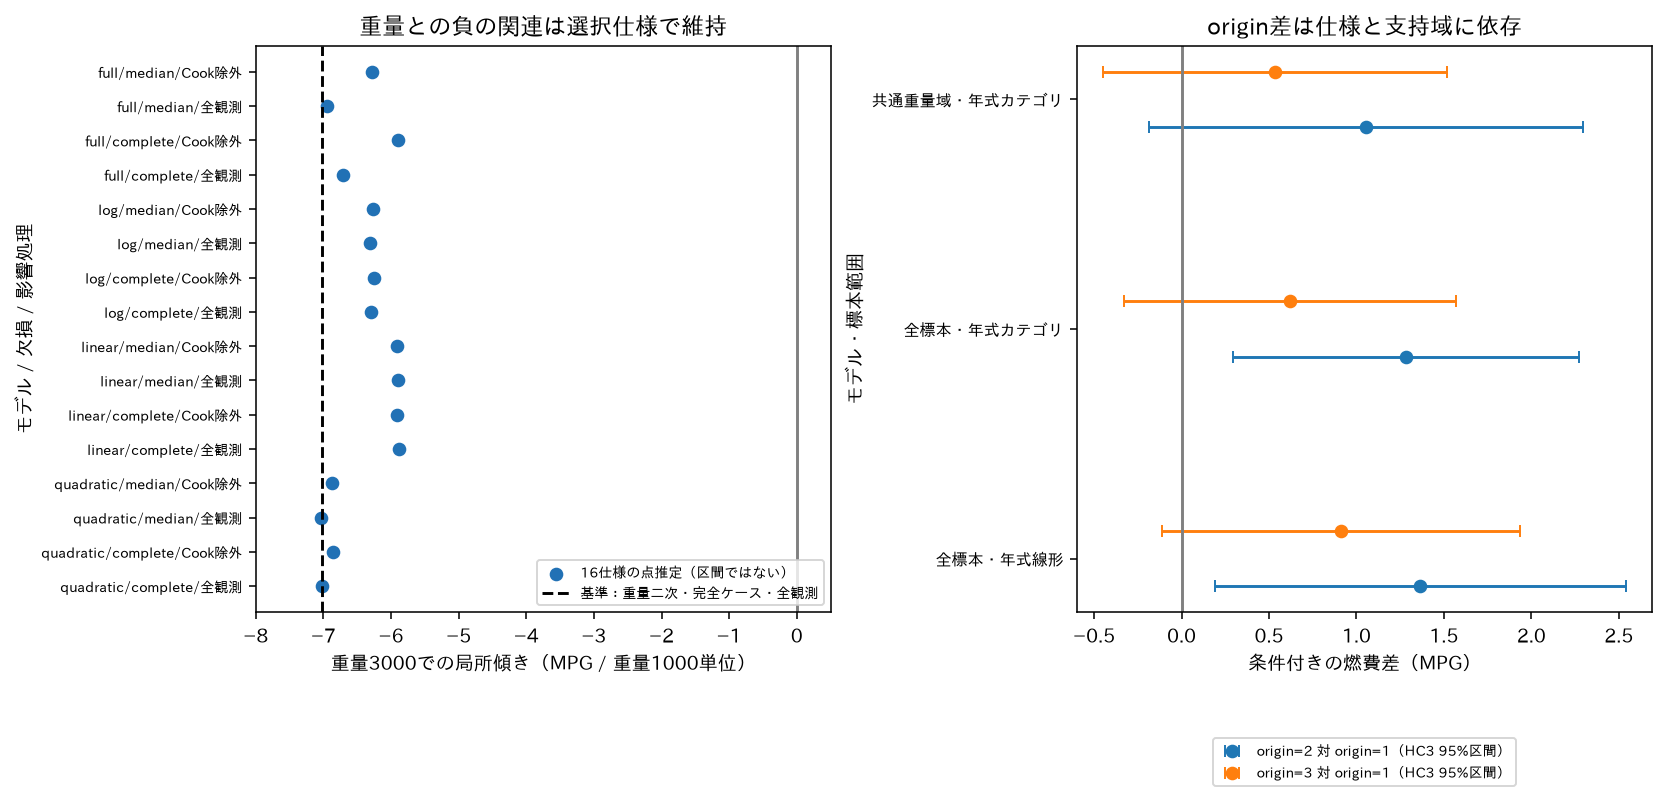

In [10]:
# FIG_SENSITIVITY: 選択仕様の変動幅とoriginの支持域比較
start_phase('最終図表')
try:
    fig, axes = plt.subplots(1,2,figsize=(12,6))
    ax = axes[0]
    positions = np.arange(len(sensitivity_table))
    text_labels = [f"{r.model}/{r.missing}/{'Cook除外' if r.influence=='exclude_cook' else '全観測'}" for r in sensitivity_table.itertuples()]
    ax.scatter(sensitivity_table.weight_slope_at3000,positions,label='16仕様の点推定（区間ではない）',color='#2171b5')
    ax.axvline(0,color='gray')
    ax.axvline(weight_sensitivity.baseline_value,color='black',linestyle='--',label='基準：重量二次・完全ケース・全観測')
    ax.set_yticks(positions,text_labels,fontsize=7)
    ax.set(xlim=(-8,0.5),xlabel='重量3000での局所傾き（MPG / 重量1000単位）',ylabel='モデル / 欠損 / 影響処理',title='重量との負の関連は選択仕様で維持')
    ax.legend(fontsize=7,loc='lower right')
    ax2=axes[1]
    for code,offset in [(2,-.12),(3,.12)]:
        points=origin_comparison[origin_comparison.origin_vs1==f'C(origin)[T.{code}]'].reset_index(drop=True)
        y=np.arange(len(points))+offset
        ax2.errorbar(points.coefficient,y,xerr=[points.coefficient-points.CI_low,points.CI_high-points.coefficient],fmt='o',capsize=3,label=f'origin={code} 対 origin=1（HC3 95%区間）')
    ax2.set_yticks(np.arange(3),origin_comparison.specification.drop_duplicates(),fontsize=8)
    ax2.axvline(0,color='gray')
    ax2.set(xlabel='条件付きの燃費差（MPG）',ylabel='モデル・標本範囲',title='origin差は仕様と支持域に依存')
    ax2.legend(fontsize=7,loc='lower center',bbox_to_anchor=(.5,-.32))
    fig.tight_layout()
    render_figure(fig,'FIG_SENSITIVITY','感度仕様とorigin比較','局所重量傾き / origin燃費差','仕様 / 標本範囲','16仕様の点推定、基準、origin2/3のHC3区間')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('最終図表')


In [11]:
# STREAM_ONLY_PROBE: stream出力への根拠参照を再現
print('JUPYTERMIND_STREAM_ONLY_SENTINEL=v020-exp-07-stream-probe')


JUPYTERMIND_STREAM_ONLY_SENTINEL=v020-exp-07-stream-probe


In [12]:
# FINAL_MANIFESTS_AND_PROBES: 最終前提と改善候補の再現ログ
start_phase('前提と改善候補')
try:
    from ai_data_scientist import notebook_audit, insight_engine
    import importlib.metadata
    current_nb = nbformat.read(handle.notebook_path,as_version=4)
    stream_cell = next(c for c in current_nb.cells if c.cell_type=='code' and c.source.startswith('# STREAM_ONLY_PROBE'))
    try:
        insight_engine.record_insight(handle,'監査再現probe（分析Insightではない）',stream_cell.execution_count,'v020-exp-07-stream-probe','diagnostic',language='ja')
    except insight_engine.EvidenceMissingError as exc:
        stream_probe = {'reproduced':True,'exception':type(exc).__name__,'cell_id':stream_cell.id,
                        'execution_count':stream_cell.execution_count,'actual':'streamには値があるが根拠として参照不可'}
    else:
        stream_probe = {'reproduced':False,'actual':'SDKがstreamを受理したため改善済みの可能性'}
        write_nb(lambda nb: setattr(nb,'cells',[c for c in nb.cells if not(c.cell_type=='markdown' and c.source.startswith('監査再現probe'))]))
    actual_chart = next(c for c in current_nb.cells if c.cell_type=='code' and c.source.startswith('# FIG_INITIAL'))
    cloned_chart = nbformat.from_dict(json.loads(json.dumps(actual_chart)))
    cloned_chart.metadata = {}
    in_memory_probe = nbformat.v4.new_notebook(cells=[cloned_chart])
    metadata_probe_findings = notebook_audit.audit_visual_outputs(in_memory_probe,(0,))
    metadata_probe = {'missing_chart_metadata_findings':[asdict(f) for f in metadata_probe_findings],
                      'metadata_absent':not bool(cloned_chart.metadata),'actual_chart_cell_id':actual_chart.id}
    improvement_logs = {'stream_evidence':stream_probe,'missing_chart_metadata':metadata_probe}
    probe_path = data_dir/'write-safety-probe.ipynb'
    probe_handle = project_manager.ProjectHandle(handle.name,handle.root,probe_path,handle.data_dir)
    lifecycle.mark_write_start(run_id)
    try:
        project_manager.ensure_notebook(probe_handle)
        original_size = probe_path.stat().st_size
        try:
            project_manager.enqueue_write(probe_handle,lambda nb: nb.metadata.update({'font_path':font_manager.findfont(font_manager.FontProperties(family=plt.rcParams['font.family']))}))
        except TypeError as exc:
            write_safety_probe = {'exception':type(exc).__name__,'message':str(exc),'bytes_before':original_size,'bytes_after_failure':probe_path.stat().st_size,'main_notebook_not_used':True}
        else:
            write_safety_probe = {'exception':None,'bytes_after_failure':probe_path.stat().st_size,'reproduced':False}
    finally:
        if probe_path.exists():
            probe_path.unlink()
        lifecycle.mark_write_end(run_id)
    improvement_logs['non_atomic_serialization'] = write_safety_probe
    print('JUPYTERMIND_IMPROVEMENT_LOGS:',json.dumps(improvement_logs,ensure_ascii=False))
    final_assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target':'398観察車両; 調整の主分析392完全ケース','limits':'中心重量域での関連。稀な重量域や現代車に一般化しない'},causal_scope='associational',
        sampling={'n':len(df),'seed':20261002,'mode':'全観測; 反復CV・群CVで診断'},
        assumptions=(
            analysis_assumptions.Assumption('missing','6件の馬力欠損の除外/中央値補完で主要関連の方向は同じ','tested',impact_if_false='非無作為欠損の未測定バイアスはなお残る',conclusion_critical=True),
            analysis_assumptions.Assumption('functional','重量3000の局所傾きと年式関連は指定16仕様で符号と20%以内の大きさを維持','tested',impact_if_false='未検証の関数形や重量域では変わり得る',conclusion_critical=True),
            analysis_assumptions.Assumption('linear_global','全重量域で一定の線形傾きが十分','rejected',impact_if_false='線形係数の全域解釈は採用しない',conclusion_critical=False),
            analysis_assumptions.Assumption('iid','標本依存を車名/年式clusterだけで十分捉えた','assumed',impact_if_false='95%区間に残る不確実性。近似区間としてのみ扱う',conclusion_critical=True),
            analysis_assumptions.Assumption('causal','介入効果がこの観察標本から識別される','rejected',impact_if_false='因果結論不可'),
            analysis_assumptions.Assumption('generalize','現代車や全市場に代表性がある','rejected',impact_if_false='一般化不可')))
    final_assumption_findings = analysis_assumptions.check_manifest(final_assumptions)
    print('FINAL_ASSUMPTION_MANIFEST:',json.dumps(asdict(final_assumptions),ensure_ascii=False,indent=2))
    print('最終前提チェック・全指摘:',[asdict(f) for f in final_assumption_findings])
    versions = {name:importlib.metadata.version(name) for name in ['numpy','pandas','scipy','statsmodels','scikit-learn','matplotlib','kaggle','nbformat']}
    print('実行環境:', {'Python':sys.version.split()[0],**versions})
    lifecycle.mark_write_start(run_id)
    try:
        (data_dir/'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest),ensure_ascii=False,default=str,indent=2),encoding='utf-8')
        (data_dir/'analysis-assumption-manifest.json').write_text(json.dumps(asdict(final_assumptions),ensure_ascii=False,indent=2),encoding='utf-8')
        (data_dir/'jupytermind-improvement-logs.json').write_text(json.dumps(improvement_logs,ensure_ascii=False,indent=2),encoding='utf-8')
    finally:
        lifecycle.mark_write_end(run_id)
    print('適用しない機能: 独立参照データ照合/dataset_validation（独立資料なし）、自動探索モジュール（Kaggle SDKで探索）、単一変数z-score除去（車群の多峰性を異常としない）、因果推定（識別条件なし）、AutoML/NLP/クラスタリング（目的外）。')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('前提と改善候補')


JUPYTERMIND_IMPROVEMENT_LOGS: {"stream_evidence": {"reproduced": true, "exception": "EvidenceMissingError", "cell_id": "4df1bd11", "execution_count": 11, "actual": "streamには値があるが根拠として参照不可"}, "missing_chart_metadata": {"missing_chart_metadata_findings": [], "metadata_absent": true, "actual_chart_cell_id": "ca456783"}, "non_atomic_serialization": {"exception": "TypeError", "message": "FontPath.__new__() missing 1 required positional argument: 'face_index'", "bytes_before": 72, "bytes_after_failure": 0, "main_notebook_not_used": true}}
FINAL_ASSUMPTION_MANIFEST: {
  "analysis_scope": {
    "target": "398観察車両; 調整の主分析392完全ケース",
    "limits": "中心重量域での関連。稀な重量域や現代車に一般化しない"
  },
  "assumptions": [
    {
      "id": "missing",
      "statement": "6件の馬力欠損の除外/中央値補完で主要関連の方向は同じ",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": "非無作為欠損の未測定バイアスはなお残る",
      "conclusion_critical": true
    },
    {
      "id": "functional",
      "statement": "重量3000の局所傾きと年式関連は指定16仕様で符号と

## 使用したJupytermindモジュール
直接importし、実際に呼び出したもののみ。第三者ライブラリ（Kaggle SDK、pandas、SciPy、statsmodels、scikit-learn、matplotlib、nbformat）はこの表に含めない。

| モジュール（ai_data_scientist配下） | 直接利用した関数・クラス・メソッド | 使用目的 |
|---|---|---|
| project_manager | ProjectHandle, resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定slug・安定パス・単一writer保存 |
| language_router | detect_language | 日本語指示の確認 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込み・失敗・完了の追跡 |
| ingestion | SourceSpec, ingest | Kaggle取得済みローカルCSVの取込みと上限確認 |
| cleaning | clean_dataset | 重複除去、完全ケース、馬力中央値補完と影響報告 |
| eda | explore | 型・欠損・記述統計・車名カテゴリ概要 |
| stats_analysis | correlation | 日本語解釈付きPearson相関 |
| visualization | render_chart, build_image_output | 日本語散布図、PNG MIME保存 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 定義・単位・出典の確信度と未知項目 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 前提と非因果スコープ、未解決リスク |
| data_quality | detect_anomalies | 欠損・カテゴリ・値域・車名ユニーク性の意味的検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 16仕様の局所重量傾きと年式係数の安定性 |
| insight_engine | extract_cited_value, record_insight | 実出力からの引用と構造化根拠付きInsight、stream問題の再現 |
| notebook_audit | audit_visual_outputs, audit_notebook | metadata欠落問題の再現とvisual_audit=True監査 |

`mcp_gateway`, `dataset_validation`, `anomaly_detection`, `dependency_pins` 等は直接呼び出していないため、利用済みと数えない。間接内部利用も利用済みに追加しない。


## Jupytermind改善候補

### 1. stream出力を根拠参照できない（不具合候補）
- 分類: `insight_engine` の根拠出力形式の対応不足。Kaggle API/CLI/ランナーとは独立。
- 再現条件: `STREAM_ONLY_PROBE`セルをMCPで実行し、その実execution_countと出力文字列 `v020-exp-07-stream-probe` を `record_insight` に渡す。
- 期待: 実行済みの標準出力内の値も根拠として検証できる。または対応出力形式をAPI契約で明示する。
- 実際: `EvidenceMissingError`。初回統計セルの実stream中の `-0.831741` でも同じ例外を確認。探索先がoutput.dataのみでstream.textを参照しない。
- 影響: printした統計は実行済みでもそのままInsightの根拠にできない。
- 回避策: `emit_evidence`で同じ実測値を`display_data`のtext/plain MIMEとして表示する。根拠値やexecution_countの捏造はしない。
- 関連セル・ログ: `STREAM_ONLY_PROBE`、`FINAL_MANIFESTS_AND_PROBES`、`JUPYTERMIND_IMPROVEMENT_LOGS`、data/jupytermind-improvement-logs.json。初回診断はbootstrapセル6の`JUPYTERMIND_STREAM_PROBE`。

### 2. chart metadataが丸ごとない場合に視覚監査が見逃す（機能不足候補）
- 分類: `notebook_audit.audit_visual_outputs` の監査網羅性。Jupyter MCPの図保存やCLI表示と切り分ける。
- 再現条件: 実図表セルをメモリ内でコピーしmetadataを空にして `audit_visual_outputs` を呼び出す。
- 期待: 字形監査のmetadata、タイトル・軸・凡例のmetadata欠落が指摘される。
- 実際: metadata全体が空だと`missing_chart_metadata_findings=[]`。missing_glyphs未記録も指摘されない。
- 影響: visual_audit=Trueの合格だけでは字形やラベルの検証済みを保証しない。
- 回避策: 全図表のmetadataを明示し、実フォントの文字被覆、Glyph描画警告、PNGサイズを別途検査する。図を目視でも読み直す。
- 関連セル・ログ: `FINAL_MANIFESTS_AND_PROBES`、`FIG_*`、同じ改善ログJSON。

Kaggle SDKのdataset_view不存在、Jupyter MCP初期ディレクトリ作成制約、独自FontPropertiesの型誤りはJupytermind固有の候補に含めない。改善候補は報告のみでライブラリ実装を変更しない。


### 3. シリアライズ失敗で既存Notebookを切り詰める（不具合候補）
分類: project_manager.enqueue_writeの非atomic保存。再現条件: matplotlib 3.11のFontPath（str派生型）をmetadataに入れてenqueue_writeする。nbformat.validateは通るがdeepcopyでTypeErrorとなる。期待: シリアライズ完了前に保存先を開かず、失敗時は既存ファイルを保持する。実際: open('w')後にnbformat.writeが失敗し、保存先が0バイトになる（専用probeファイルで再現ログを記録）。影響: 失敗時に既存Notebook破損の恐れ。回避策: FontPathを明示的にstr化し、出力を書き込む前にJSON互換性を確認する。主Notebookはprobeに用いない。関連セル/ログ: FINAL_MANIFESTS_AND_PROBES、COMPILE_INSIGHTSの最初の再実行失敗、non_atomic_serializationログ。直接の例外はmatplotlib/nbformatの型互換性だが、失敗前に既存ファイルを切り詰める挙動はJupytermindのwriter責務として別分類する。


## 観察データの限界と結論の扱い
このCSVの市街地サイクルMPGに対する**関連**を調べた。重量・排気量・馬力・気筒数は強く共変動しており、重量だけを変更する介入とは異なる。空力、変速機、燃料、技術、規制、メーカー等の未観測交絡が残り、軽量化やoriginの因果効果は識別できない。年式との関連も技術等の時代変化を含む。

データは年式コード70–82の歴史的車両で、抽出母集団や代表性が不明。元データからMPG不明8件が除かれ、さらに主モデルは馬力欠損6件を除いた392台である。感度の中央値補完は非無作為欠損を解決しない。車名の重複149行は同一測定149行の重複を意味せず、完全重複は0件。独立参照データがないので誤記を独立検証してはいない。

重量のlb、排気量のcubic inches、加速の秒/0-60mph、年式の西暦対応などは出典で未確認のため推定。MPGのガロン規格も不明なのでkm/Lに換算しない。originの国・地域名は推測しない。出典の「車名はユニーク」という説明と実値の重複を区別して記録した。

相関の95%区間と回帰のHC3/cluster区間は近似。13年式clusterは少数群で、残る標本依存は`assumed`警告として開示する。共通支持域は一変数の最小最大によるもので、完全なマッチングではない。重い車両域の曲線折返しはモデル依存で解釈を保留。16仕様のstableは指定仕様と20%閾値に限り、年式変動は閾値近くに達する。CVはこのデータのモデル診断であり、現代車・新規市場・将来年式への外部保証ではない。留一年式法は主に補間の診断で、厳密な将来予測評価ではない。多数の探索的比較のp値は補正していないため、独立な検定の確証とは扱わない。表の丸めたp=0.0000は厳密なゼロではない。

## 反復3の結果・証拠・停止判断
共通重量域と年式カテゴリの調整でも重量2500での関連は負。origin差は縮小し、両群の95%区間がゼロを含む。これは群間差が存在しないとの証明ではなく、現資料で固有差を強く主張できないという結果。証拠は`ITERATION_3`と根拠付きInsight、origin比較図。

3回の反復で、関数形・欠損・影響点・標本依存・比較の支持域という結論に影響する論点を点検した。残る因果識別、母集団代表性、測定単位、稀な重量域の形状は同じ標本の追加モデルだけでは解消できない。ユーザーの上限3回にも達したため、追加のモデル探索で「確証」を増やすより、これらを限界として明示して停止する。各追加依頼の原文は反復依頼履歴に保持した。

## 根拠付きInsight
以下のInsightは、コードセルの実MIME出力から引用値を抽出し、その実execution_countを検証して記録する。再実行では古いInsightを置換し、引用を更新する。


Insight 1：この398台では重量と燃費のPearson相関は -0.832（強い負の関連）。排気量・馬力・気筒数も負の周辺相関を示すが、重量等と強く共変動するため独立の燃費要因として単純に順位付けできない。

```evidence
{"execution_count":4,"cited_value":"-0.831741","claim_type":"associational"}
```

Insight 2：年式コードと燃費は正の周辺相関 r=0.579。後の年式ほど燃費が高い傾向だが、技術・規制・車種構成等が同時に変化しており、年式自体の介入効果ではない。

```evidence
{"execution_count":4,"cited_value":"0.579267","claim_type":"associational"}
```

Insight 3：全特性線形モデルの最大VIFは 22.94。共線性のため、周辺相関と調整係数の符号が一致しない特性がある。排気量の正の調整係数を「大排気量なら燃費が改善する」と解釈してはいけない。

```evidence
{"execution_count":4,"cited_value":"22.937950","claim_type":"associational"}
```

Insight 4（反復1）：年式・originを含む簡潔モデルで重量二次項を入れると、共通の反復CVでRMSEが 3.36 から 3.03 MPGに低下（10.0%改善）。曲線性は実質的に重要。全特性の非線形モデルにはさらに小さい改善があり、その他の特性が無関係とは結論しない。

```evidence
{"execution_count":6,"cited_value":"3.025907","claim_type":"associational"}
```

Insight 5（反復2）：重量3000の局所傾きは、指定16仕様で重量1000記録単位あたり -7.04〜-5.89 MPG。全仕様で負、最大相対変動16.2%、stable=True（許容20%）。これは中心域での条件付き関連で、1000単位軽量化したときの因果効果ではない。重量単位lbは未検証の推定。

```evidence
{"execution_count":8,"cited_value":"-7.040943","claim_type":"associational"}
```

Insight 6（反復2）：調整後の年式コード1単位あたり燃費関連は 0.673〜0.840 MPGで、全仕様で正。stable=Trueだが最大相対変動は19.7%と20%閾値に近い。車名/年式cluster区間でも正方向だが、13年式群しかなく区間は近似である。独立性は未解決リスクとして残す。

```evidence
{"execution_count":8,"cited_value":"0.672964","claim_type":"associational"}
```

Insight 7（反復3）：共通重量域1825〜2930の204台で年式をカテゴリ調整すると、origin=1に対する差はorigin=2で1.06 MPG、origin=3で0.54 MPG。どちらもHC3の95%区間がゼロを含む。差がないとの証明でもorigin固有の因果効果の証明でもない。国ラベルは未確認のためコードのまま扱う。

```evidence
{"execution_count":9,"cited_value":"204","claim_type":"associational"}
```

Insight 8：重量5000付近（±250）の観測は6台のみ。二次モデルは重い領域で折り返す一方、対数モデルは負の局所傾きを保つ。形状はモデル依存で、重い車両ほど燃費が良くなるとは結論できない。

```evidence
{"execution_count":8,"cited_value":"6","claim_type":"associational"}
```

In [13]:
# COMPILE_INSIGHTS: 実出力から引用し、再実行時に根拠を更新
start_phase('根拠付きInsight記録')
try:
    from ai_data_scientist import insight_engine
    stage_handle = project_manager.ProjectHandle(handle.name,handle.root,data_dir/'evidence-staging.ipynb',handle.data_dir)
    project_manager.ensure_notebook(stage_handle)
    def write_stage(mutation):
        lifecycle.mark_write_start(run_id)
        try:
            return project_manager.enqueue_write(stage_handle,mutation)
        finally:
            lifecycle.mark_write_end(run_id)
    snapshot = nbformat.read(handle.notebook_path,as_version=4)
    write_stage(lambda nb: (setattr(nb,'cells',snapshot.cells),setattr(nb,'metadata',snapshot.metadata)))
    def remove_generated_insights(nb):
        nb.cells = [c for c in nb.cells if not c.metadata.get('generated_auto_mpg_insight')]
    write_stage(remove_generated_insights)
    evidence_nb = nbformat.read(handle.notebook_path,as_version=4)
    def evidence_for(source_tag, key):
        cell = next(c for c in evidence_nb.cells if c.cell_type=='code' and c.source.startswith(source_tag))
        data_output = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in cell.outputs)
        result = {'output':data_output}
        value = insight_engine.extract_cited_value(result,key + r'=([-+]?\d+(?:\.\d+)?)')
        return cell.execution_count,value
    def save_insight(text,count,value):
        lifecycle.mark_write_start(run_id)
        try:
            insight_engine.record_insight(stage_handle,text,count,value,'associational',language='ja')
        finally:
            lifecycle.mark_write_end(run_id)
        write_stage(lambda nb: nb.cells[-1].metadata.update({'generated_auto_mpg_insight':True}))
    count,r = evidence_for('# 初回分析:', 'EVIDENCE_WEIGHT_R')
    save_insight(f'Insight 1：この398台では重量と燃費のPearson相関は {float(r):.3f}（強い負の関連）。排気量・馬力・気筒数も負の周辺相関を示すが、重量等と強く共変動するため独立の燃費要因として単純に順位付けできない。',count,r)
    count,r = evidence_for('# 初回分析:', 'EVIDENCE_YEAR_R')
    save_insight(f'Insight 2：年式コードと燃費は正の周辺相関 r={float(r):.3f}。後の年式ほど燃費が高い傾向だが、技術・規制・車種構成等が同時に変化しており、年式自体の介入効果ではない。',count,r)
    count,vif = evidence_for('# 初回分析:', 'EVIDENCE_MAX_VIF')
    save_insight(f'Insight 3：全特性線形モデルの最大VIFは {float(vif):.2f}。共線性のため、周辺相関と調整係数の符号が一致しない特性がある。排気量の正の調整係数を「大排気量なら燃費が改善する」と解釈してはいけない。',count,vif)
    count,quad = evidence_for('# ITERATION_1:', 'EVIDENCE_QUADRATIC_RMSE')
    _,lin = evidence_for('# ITERATION_1:', 'EVIDENCE_LINEAR_RMSE')
    _,improve = evidence_for('# ITERATION_1:', 'EVIDENCE_RMSE_IMPROVEMENT')
    save_insight(f'Insight 4（反復1）：年式・originを含む簡潔モデルで重量二次項を入れると、共通の反復CVでRMSEが {float(lin):.2f} から {float(quad):.2f} MPGに低下（{float(improve)*100:.1f}%改善）。曲線性は実質的に重要。全特性の非線形モデルにはさらに小さい改善があり、その他の特性が無関係とは結論しない。',count,quad)
    count,low = evidence_for('# ITERATION_2:', 'EVIDENCE_SENSITIVITY_WEIGHT_MIN')
    _,high = evidence_for('# ITERATION_2:', 'EVIDENCE_SENSITIVITY_WEIGHT_MAX')
    _,dev = evidence_for('# ITERATION_2:', 'EVIDENCE_WEIGHT_MAX_DEVIATION')
    save_insight(f'Insight 5（反復2）：重量3000の局所傾きは、指定16仕様で重量1000記録単位あたり {float(low):.2f}〜{float(high):.2f} MPG。全仕様で負、最大相対変動{float(dev)*100:.1f}%、stable={weight_sensitivity.stable}（許容20%）。これは中心域での条件付き関連で、1000単位軽量化したときの因果効果ではない。重量単位lbは未検証の推定。',count,low)
    count,low = evidence_for('# ITERATION_2:', 'EVIDENCE_SENSITIVITY_YEAR_MIN')
    _,high = evidence_for('# ITERATION_2:', 'EVIDENCE_SENSITIVITY_YEAR_MAX')
    _,dev = evidence_for('# ITERATION_2:', 'EVIDENCE_YEAR_MAX_DEVIATION')
    save_insight(f'Insight 6（反復2）：調整後の年式コード1単位あたり燃費関連は {float(low):.3f}〜{float(high):.3f} MPGで、全仕様で正。stable={year_sensitivity.stable}だが最大相対変動は{float(dev)*100:.1f}%と20%閾値に近い。車名/年式cluster区間でも正方向だが、13年式群しかなく区間は近似である。独立性は未解決リスクとして残す。',count,low)
    count,n = evidence_for('# ITERATION_3:', 'EVIDENCE_OVERLAP_N')
    _,origin2 = evidence_for('# ITERATION_3:', 'EVIDENCE_OVERLAP_ORIGIN2')
    _,origin3 = evidence_for('# ITERATION_3:', 'EVIDENCE_OVERLAP_ORIGIN3')
    save_insight(f'Insight 7（反復3）：共通重量域{overlap_low:.0f}〜{overlap_high:.0f}の{n}台で年式をカテゴリ調整すると、origin=1に対する差はorigin=2で{float(origin2):.2f} MPG、origin=3で{float(origin3):.2f} MPG。どちらもHC3の95%区間がゼロを含む。差がないとの証明でもorigin固有の因果効果の証明でもない。国ラベルは未確認のためコードのまま扱う。',count,n)
    count,n = evidence_for('# ITERATION_2:', 'EVIDENCE_TAIL5000_COUNT')
    save_insight(f'Insight 8：重量5000付近（±250）の観測は{n}台のみ。二次モデルは重い領域で折り返す一方、対数モデルは負の局所傾きを保つ。形状はモデル依存で、重い車両ほど燃費が良くなるとは結論できない。',count,n)
    def arrange_and_metadata(nb):
        generated = [c for c in nb.cells if c.metadata.get('generated_auto_mpg_insight')]
        other = [c for c in nb.cells if not c.metadata.get('generated_auto_mpg_insight')]
        index = next(i for i,c in enumerate(other) if c.cell_type=='code' and c.source.startswith('# COMPILE_INSIGHTS'))
        nb.cells = other[:index]+generated+other[index:]
        for cell in nb.cells:
            if cell.cell_type=='code':
                for tag,chart_info in figure_registry.items():
                    if cell.source.startswith('# '+tag+':'):
                        cell.metadata['chart'] = chart_info
        nb.metadata['data_provenance'] = provenance
        nb.metadata['analysis_assumptions'] = asdict(final_assumptions)
        nb.metadata['assumption_findings'] = [asdict(f) for f in final_assumption_findings]
        nb.metadata['jupytermind_improvements'] = improvement_logs
        nb.metadata['package_versions'] = versions
    write_stage(arrange_and_metadata)
    print('実出力から抽出した8件のInsightを隔離stagingへ記録。MCPセル実行終了後に単一writerで主Notebookへ同期する。')
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('根拠付きInsight記録')


実出力から抽出した8件のInsightを隔離stagingへ記録。MCPセル実行終了後に単一writerで主Notebookへ同期する。


## 再実行・最終監査
カーネルを再起動して、準備・Kaggleの再取得・分析・図表・根拠引用の全コードセルを上からJupyter MCPで再実行する。初回とSHA-256および主要13数値をrtol=atol=1e-10で照合。最終セルは実行完了前の自分自身を監査上除外できるため、MCP保存後にも同セルの監査を再確認する。ライフサイクルcompletedと実行/書込み/lock数ゼロを確認する。

### 検証済みの再実行手順
同じカーネルに接続した補助Notebook `benchmark/auto-mpg-bootstrap-v020-exp-07.ipynb` のセル10がInsight/図表metadata同期、セル11が保存後監査の同期。主NotebookのCOMPILE_INSIGHTSまでを上からMCPで実行し、補助セル10だけを実行、その後主NotebookのFINAL_AUDITを実行、保存後に補助セル11を実行する。補助の作成セル1–9は既存Notebookを初期化するものなので再実行しない。任意の外部スクリプト/端末起動は不要。通常のJupyterLab Run Allだけではなく、ここに記録したMCP保存同期手順を含めて再現性を確認した。

In [16]:
# FINAL_AUDIT: 全セルの再実行、図表とライフサイクル
start_phase('最終監査')
try:
    from ai_data_scientist import notebook_audit
    current_numeric = {'weight_r':float(corr_table.set_index('feature').loc['weight','Pearson_r']),
        'year_r':float(corr_table.set_index('feature').loc['model_year','Pearson_r']),
        'reduced_weight':float(reduced_fit.params['I(weight / 1000)']),
        'quadratic_year':float(nonlinear_fit.params['model_year']),
        'weight_max_relative_deviation':weight_sensitivity.max_relative_deviation,
        'year_max_relative_deviation':year_sensitivity.max_relative_deviation,
        'overlap_n':len(overlap), 'overlap_origin2':float(overlap_fit.params['C(origin)[T.2]']),
        'overlap_origin3':float(overlap_fit.params['C(origin)[T.3]'])}
    current_numeric.update({f'cv_RMSE_{i}':float(row.pooled_RMSE) for i,row in cv_table.iterrows()})
    persisted_nb = nbformat.read(handle.notebook_path,as_version=4)
    baseline = persisted_nb.metadata['first_pass_baseline']
    if provenance['sha256'] != baseline['sha256']:
        raise RuntimeError('再取得CSVのSHA-256が初回と異なるため再現比較を中止')
    deviations = {key:abs(float(value)-float(baseline['numeric'][key])) for key,value in current_numeric.items()}
    if not all(np.isclose(value,baseline['numeric'][key],rtol=1e-10,atol=1e-10) for key,value in current_numeric.items()):
        raise RuntimeError('初回と再実行の主要数値が一致しない: '+str(deviations))
    code_cells = [c for c in persisted_nb.cells if c.cell_type=='code']
    counts_before_audit = [c.execution_count for c in code_cells if not c.source.startswith('# FINAL_AUDIT')]
    if not all(isinstance(c,int) for c in counts_before_audit) or counts_before_audit != sorted(counts_before_audit) or len(set(counts_before_audit)) != len(counts_before_audit):
        raise RuntimeError('コードセルの上から順の実行が確認できない: '+str(counts_before_audit))
    chart_cells = [c for c in code_cells if any('image/png' in o.get('data',{}) for o in c.outputs)]
    for c in chart_cells:
        chart = c.metadata.get('chart',{})
        if any(not chart.get(key) for key in ['title','xlabel','ylabel','legend']) or 'missing_glyphs' not in chart or chart['missing_glyphs']:
            raise RuntimeError('図表metadataの完全性/字形監査に失敗: '+c.id)
    audit_report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    if not audit_report.ok or audit_report.visual_findings:
        raise RuntimeError('Notebook監査に失敗: '+str(asdict(audit_report)))
    print('NOTEBOOK_AUDIT:', json.dumps({'ok':audit_report.ok,**asdict(audit_report)},ensure_ascii=False,indent=2))
    replay_record = {'method':'Jupyter MCPでカーネルを再起動し全コードセルを上からexecute_cell',
                     'sha256_matches_first_pass':True,'numeric_values_match_first_pass':True,
                     'max_absolute_numeric_deviation':max(deviations.values()),'numeric_tolerance':{'rtol':1e-10,'atol':1e-10},
                     'execution_counts_before_final_audit':counts_before_audit,'code_cell_count':len(code_cells),
                     'at_utc':datetime.now(timezone.utc).isoformat()}
    print('REPLAY_VERIFICATION:',json.dumps(replay_record,ensure_ascii=False))
except Exception:
    lifecycle.mark_failed(run_id)
    raise
finally:
    end_phase('最終監査')
lifecycle.mark_completed(run_id)
quiescent = lifecycle.wait_for_quiescence(run_id,timeout_s=5)
if quiescent.state != 'completed' or any([quiescent.active_cell_executions,quiescent.pending_notebook_writes,quiescent.locks_held]):
    lifecycle.mark_failed(run_id)
    raise RuntimeError('ライフサイクルがcompleted/静止状態でない')
def persist_final_audit(nb):
    nb.metadata['final_audit'] = {'ok':audit_report.ok,**asdict(audit_report)}
    nb.metadata['replay_verification'] = replay_record
    nb.metadata['lifecycle'] = asdict(quiescent)
    nb.metadata['phase_log'] = phase_log
lifecycle.mark_write_start(run_id)
try:
    (data_dir/'final-run-record.json').write_text(json.dumps({'audit':{'ok':audit_report.ok,**asdict(audit_report)},'replay':replay_record,'lifecycle':asdict(quiescent),'phase_log':phase_log},ensure_ascii=False,indent=2),encoding='utf-8')
finally:
    lifecycle.mark_write_end(run_id)
# 主Notebookのmetadata同期はこのセルのMCP保存後に外側から行う。
final_status = lifecycle.get_run_status(run_id)
print('FINAL_LIFECYCLE:',json.dumps(asdict(final_status),ensure_ascii=False))
print('前提上の残る警告:',[asdict(f) for f in final_assumption_findings])
print('図表監査: 字形metadata、ラベル、凡例、PNG密度を点検済み。自動監査は視覚的正しさ全体の保証ではない。')


NOTEBOOK_AUDIT: {
  "ok": true,
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-07-auto-mpg/notebooks/kaggle-v020-kaggle-exp-07-auto-mpg.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 14,
  "executed_code_cell_count": 14,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    9,
    12,
    19
  ],
  "insight_cell_count": 8,
  "findings": [],
  "visual_findings": []
}
REPLAY_VERIFICATION: {"method": "Jupyter MCPでカーネルを再起動し全コードセルを上からexecute_cell", "sha256_matches_first_pass": true, "numeric_values_match_first_pass": true, "max_absolute_numeric_deviation": 0.0, "numeric_tolerance": {"rtol": 1e-10, "atol": 1e-10}, "execution_counts_before_final_audit": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], "code_cell_count": 14, "at_utc": "2026-10-01T16:41:58.740821+00:00"}
FINAL_LIFECYCLE: {"run_id": "v020-exp-07", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "note